# Reto 1 EPAM: Análisis de Reseñas de FlowApp con DuckDB

**Autor:** Isaac David  
---


In [11]:
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt

In [12]:
DS = "./resenas_flowapp.csv"

OUT = Path("./out/")
OUT.mkdir(exist_ok=True)

DB_FILE = OUT / "flowapp_analysis.duckdb"
con = duckdb.connect(str(DB_FILE))

## 0. Descubrimiento de Datos (Exploratory Data Analysis - EDA)

Antes de realizar la limpieza y transformación, ejecutamos un análisis exploratorio preliminar sobre el dataset crudo `resenas_flowapp.csv`:
- **Conteo total de registros originales**
- **Verificación de valores nulos o vacíos** en cada columna
- **Inspección de la distribución de calificaciones (ratings) crudas**, identificando valores fuera de rango o en texto (ej. `'cinco'`, `NaN`, `-1`, `6`, `7`, `'?'`, `'N/A'`)
- **Rango de fechas de las reseñas** (`MIN` y `MAX`)
- **Análisis de duplicados en el texto crudo**
- **Almacenamiento del resumen en DuckDB:** Se guarda en la tabla `eda_raw_summary`.


In [13]:
query_eda = f"""
CREATE OR REPLACE TABLE eda_raw_summary AS
SELECT 
    COUNT(*) AS total_raw_rows,
    SUM(CASE WHEN usuario IS NULL OR trim(usuario) = '' THEN 1 ELSE 0 END) AS null_empty_usuario,
    SUM(CASE WHEN fecha IS NULL THEN 1 ELSE 0 END) AS null_empty_fecha,
    SUM(CASE WHEN texto IS NULL OR trim(texto) = '' THEN 1 ELSE 0 END) AS null_empty_texto,
    SUM(CASE WHEN rating IS NULL OR trim(cast(rating as varchar)) = '' THEN 1 ELSE 0 END) AS null_empty_rating,
    COUNT(DISTINCT texto) AS unique_raw_texts,
    MIN(fecha) AS min_date,
    MAX(fecha) AS max_date
FROM '{DS}';
"""
con.execute(query_eda)

df_eda = con.query("SELECT * FROM eda_raw_summary").df()
print("=== PASO 0: RESUMEN DE DESCUBRIMIENTO DE DATOS (EDA) ===")
print(df_eda.to_string(index=False))

print("\n=== DISTRIBUCIÓN DE RATINGS EN DATOS CRUDOS ===")
df_raw_ratings = con.query(f"""
SELECT rating, COUNT(*) AS count
FROM '{DS}'
GROUP BY rating
ORDER BY count DESC
""").df()
print(df_raw_ratings.to_string(index=False))

=== PASO 0: RESUMEN DE DESCUBRIMIENTO DE DATOS (EDA) ===
 total_raw_rows  null_empty_usuario  null_empty_fecha  null_empty_texto  null_empty_rating  unique_raw_texts   min_date   max_date
            597                 0.0               0.0              26.0                9.0               543 2026-05-01 2026-07-10

=== DISTRIBUCIÓN DE RATINGS EN DATOS CRUDOS ===
rating  count
     5    219
     4    184
     3     83
     2     55
     1     34
   NaN      9
 cinco      3
    -1      2
     6      2
     7      2
     ?      2
     0      1
   N/A      1


## 1. Limpieza de Texto con DuckDB

- **Conversión a minúsculas:** Aplicación de lower(texto).
- **Eliminación de caracteres especiales:** Reemplazo de puntuación y emojis por espacios mediante regexp_replace.
- **Deduplicación:** Deduplicación de reseñas con texto idéntico usando DISTINCT, guardado en la tabla `cleaned_reviews`.
- **Normalización de calificaciones:** Mapeo de valores en palabras (ej. 'cinco' -> 5) y filtrado en el rango 1-5.
- **Almacenamiento en DuckDB:** La tabla `cleaned_reviews` se guarda en la base de datos DuckDB centralizada.


In [14]:
query_cleaning = f"""
CREATE OR REPLACE TABLE cleaned_reviews AS
WITH base_reviews AS (
    SELECT 
        trim(usuario) AS username,
        fecha AS date,
        texto AS original_text,
        -- Convert to lowercase, strip special characters/emojis and normalize spaces
        trim(regexp_replace(
            regexp_replace(lower(texto), '[^a-záéíóúüñ0-9\\s]', ' ', 'g'),
            '\\s+', ' ', 'g'
        )) AS cleaned_text,
        CASE 
            WHEN lower(trim(rating)) = 'cinco' THEN 5
            ELSE try_cast(rating AS INT)
        END AS rating
    FROM '{DS}'
    WHERE texto IS NOT NULL AND trim(texto) != ''
)
SELECT DISTINCT
    cleaned_text,
    rating
FROM base_reviews
WHERE rating BETWEEN 1 AND 5;
"""

con.execute(query_cleaning)

df_cleaned = con.query("SELECT * FROM cleaned_reviews LIMIT 10").df()
df_cleaned

,cleaned_text,rating
0,me encanta flowapp sobre todo las notificacion...,5
1,diez de diez el precio de la suscripcion super...,5
2,10 10,5
3,la mejor app que probé en mucho tiempo las not...,5
4,muy recomendada la interfaz es justo lo que ne...,5
5,la mejor app que probé en mucho tiempo la bate...,5
6,esperaba más el widget de inicio deja mucho qu...,2
7,ni fu ni fa esperaba más de la batería está bi...,3
8,increíble experiencia de principio a fin sin n...,5
9,la mejor app que probé en mucho tiempo la app ...,5


## 2. Resumen estadístico

Generamos métricas estadísticas sobre las calificaciones (ratings) utilizando funciones agregadas de DuckDB en la tabla `cleaned_reviews`:
- `total_unique_reviews`
- `avg_rating`
- `median_rating`
- `std_dev`
- `min_rating` / `max_rating`
- Rating distribution (`count`, `percentage`)


In [15]:
query_stats = """
CREATE OR REPLACE TABLE rating_stats AS
SELECT
    COUNT(*) AS total_unique_reviews,
    ROUND(AVG(rating), 2) AS avg_rating,
    MEDIAN(rating) AS median_rating,
    ROUND(STDDEV(rating), 2) AS std_dev,
    MIN(rating) AS min_rating,
    MAX(rating) AS max_rating
FROM cleaned_reviews;
"""
con.execute(query_stats)
df_stats = con.query("SELECT * FROM rating_stats").df()
print("=== RATING STATISTICAL SUMMARY ===")
print(df_stats.to_string(index=False))

query_distribution = """
CREATE OR REPLACE TABLE rating_distribution AS
SELECT 
    rating,
    COUNT(*) AS count,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM cleaned_reviews
GROUP BY rating
ORDER BY rating DESC;
"""
con.execute(query_distribution)
df_distribution = con.query("SELECT * FROM rating_distribution").df()
print("\n=== RATING DISTRIBUTION ===")
print(df_distribution.to_string(index=False))

=== RATING STATISTICAL SUMMARY ===
 total_unique_reviews  avg_rating  median_rating  std_dev  min_rating  max_rating
                  418         3.8            4.0     1.27           1           5

=== RATING DISTRIBUTION ===
 rating  count  percentage
      5    163       39.00
      4    115       27.51
      3     66       15.79
      2     41        9.81
      1     33        7.89


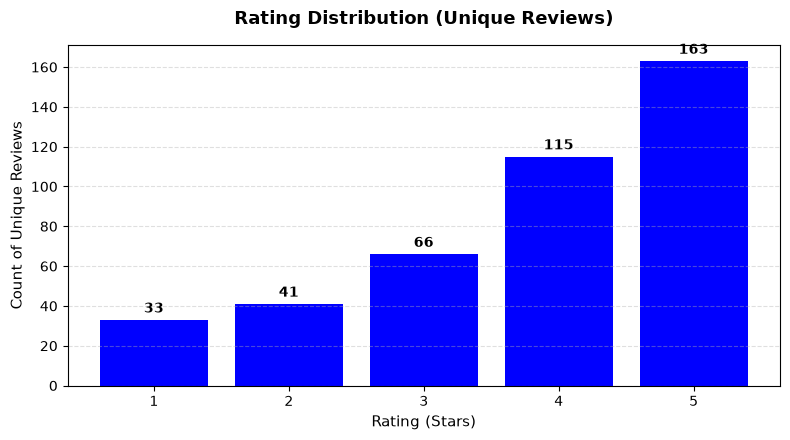

In [16]:
plt.figure(figsize=(8, 4.5))
bars = plt.bar(df_distribution["rating"], df_distribution["count"], color="blue")

plt.title(
    "Rating Distribution (Unique Reviews)", fontsize=13, fontweight="bold", pad=15
)
plt.xlabel("Rating (Stars)", fontsize=11)
plt.ylabel("Count of Unique Reviews", fontsize=11)
plt.xticks(df_distribution["rating"])
plt.grid(axis="y", linestyle="--", alpha=0.4)

for bar, count in zip(bars, df_distribution["count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        str(count),
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

## 3. Palabras más frecuentes por rating

En esta sección realizamos dos análisis comparativos para identificar las palabras más frecuentes:
1. **3.1 Versión Sin Stopwords:** Frecuencia bruta de todas las palabras tokenizadas sin exclusión.
2. **3.2 Versión Con Stopwords:** Exclusión de conectores, artículos y preposiciones comunes en español para extraer términos de valor semántico.


### 3.1 Palabras más frecuentes por rating (Sin filtrado de stopwords)

Tokenizamos el texto de `cleaned_reviews` en palabras con `unnest(string_split(...))` en DuckDB **sin aplicar filtrado de stopwords**, contabilizando la frecuencia bruta y guardando el resultado en la tabla `top_words_raw`.


In [17]:
query_top_words_raw = """
CREATE OR REPLACE TABLE top_words_raw AS
WITH tokenized_words AS (
    SELECT 
        rating,
        unnest(string_split(cleaned_text, ' ')) AS word
    FROM cleaned_reviews
),
filtered_words AS (
    SELECT 
        rating,
        word,
        COUNT(*) AS frequency
    FROM tokenized_words
    WHERE word != ''
    GROUP BY rating, word
),
ranked_words AS (
    SELECT 
        rating,
        word,
        frequency,
        ROW_NUMBER() OVER (PARTITION BY rating ORDER BY frequency DESC, word ASC) AS rank
    FROM filtered_words
)
SELECT rating, rank, word, frequency
FROM ranked_words
WHERE rank <= 5
ORDER BY rating DESC, rank ASC;
"""

con.execute(query_top_words_raw)

df_top_words_raw = con.query("SELECT * FROM top_words_raw").df()
print("=== TOP 5 WORDS BY RATING LEVEL (SIN FILTRADO DE STOPWORDS) ===")
print(df_top_words_raw.to_string(index=False))

=== TOP 5 WORDS BY RATING LEVEL (SIN FILTRADO DE STOPWORDS) ===
 rating  rank        word  frequency
      5     1          la        164
      5     2          de        104
      5     3    funciona         86
      5     4          el         63
      5     5         que         57
      4     1          la         89
      4     2      aunque         77
      4     3          un         77
      4     4       buena         55
      4     5        poco         54
      3     1          ni         42
      3     2          de         39
      3     3           a         34
      3     4       veces         32
      3     5          el         29
      2     1          no         28
      2     2          la         25
      2     3          el         19
      2     4        todo         19
      2     5    bastante         12
      1     1          la         35
      1     2          no         22
      1     3          el         18
      1     4         las         12
      1    

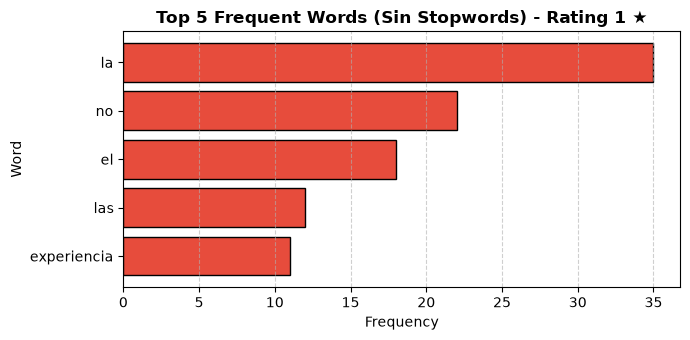

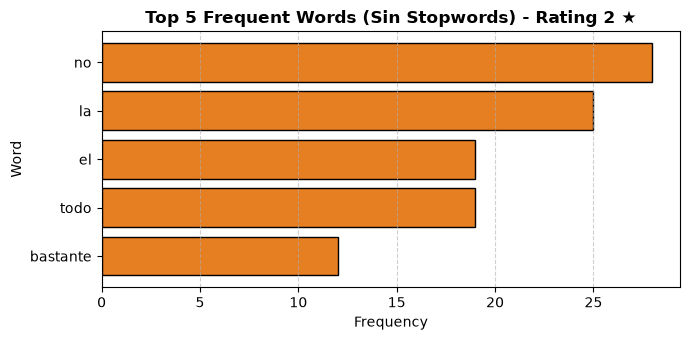

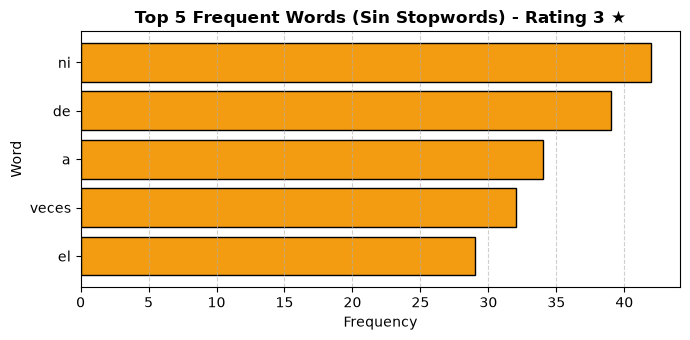

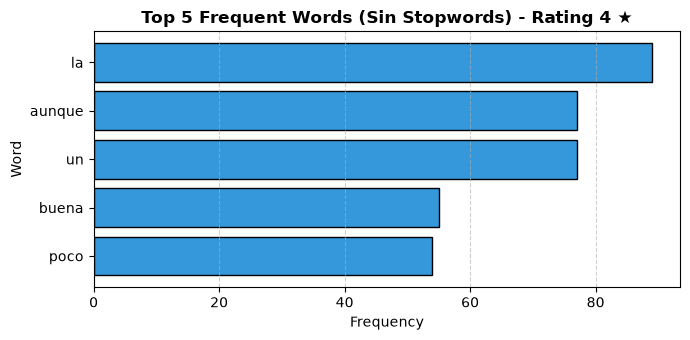

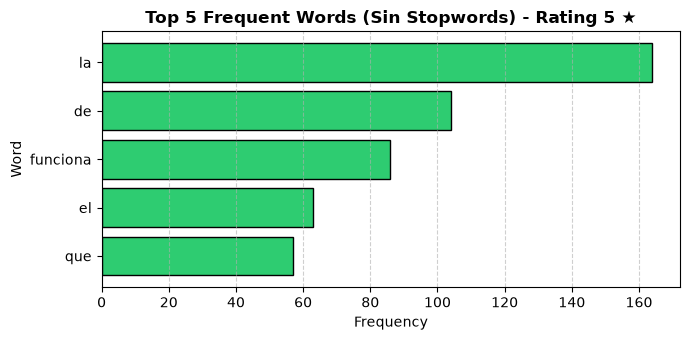

In [18]:
colors = {1: "#e74c3c", 2: "#e67e22", 3: "#f39c12", 4: "#3498db", 5: "#2ecc71"}

for r in [1, 2, 3, 4, 5]:
    plt.figure(figsize=(7, 3.5))
    sub_df = df_top_words_raw[df_top_words_raw["rating"] == r].sort_values(
        by="frequency", ascending=True
    )
    plt.barh(sub_df["word"], sub_df["frequency"], color=colors[r], edgecolor="black")
    plt.title(
        f"Top 5 Frequent Words (Sin Stopwords) - Rating {r} ★",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Frequency", fontsize=10)
    plt.ylabel("Word", fontsize=10)
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

### 3.2 Palabras más frecuentes por rating (Con filtrado de stopwords)

Aplicamos una lista de **stopwords en español** e inyectamos la condición `word NOT IN ({stopwords_sql}) AND len(word) > 2` en la consulta SQL de DuckDB. El resultado se almacena en la tabla `top_words_filtered`.


In [19]:
STOPWORDS = [
    "de",
    "del",
    "la",
    "las",
    "los",
    "les",
    "nos",
    "que",
    "el",
    "en",
    "y",
    "a",
    "un",
    "una",
    "unos",
    "unas",
    "es",
    "para",
    "con",
    "por",
]

stopwords_sql = ", ".join([f"'{w}'" for w in STOPWORDS])

query_top_words_filtered = f"""
CREATE OR REPLACE TABLE top_words_filtered AS
WITH tokenized_words AS (
    SELECT 
        rating,
        unnest(string_split(cleaned_text, ' ')) AS word
    FROM cleaned_reviews
),
filtered_words AS (
    SELECT 
        rating,
        word,
        COUNT(*) AS frequency
    FROM tokenized_words
    WHERE word != ''
      AND len(word) > 2
      AND word NOT IN ({stopwords_sql})
    GROUP BY rating, word
),
ranked_words AS (
    SELECT 
        rating,
        word,
        frequency,
        ROW_NUMBER() OVER (PARTITION BY rating ORDER BY frequency DESC, word ASC) AS rank
    FROM filtered_words
)
SELECT rating, rank, word, frequency
FROM ranked_words
WHERE rank <= 5
ORDER BY rating DESC, rank ASC;
"""

con.execute(query_top_words_filtered)

df_top_words_filtered = con.query("SELECT * FROM top_words_filtered").df()
print("=== TOP 5 WORDS BY RATING LEVEL (CON FILTRADO DE STOPWORDS) ===")
print(df_top_words_filtered.to_string(index=False))


=== TOP 5 WORDS BY RATING LEVEL (CON FILTRADO DE STOPWORDS) ===
 rating  rank          word  frequency
      5     1      funciona         86
      5     2           sin         56
      5     3          diez         54
      5     4         mejor         52
      5     5           app         46
      4     1        aunque         77
      4     2         buena         55
      4     3          poco         54
      4     4      bastante         49
      4     5          bien         49
      3     1         veces         32
      3     2          pero         29
      3     3           más         27
      3     4           app         22
      3     5      esperaba         20
      2     1          todo         19
      2     2      bastante         12
      2     3 decepcionante         12
      2     4         sobre         12
      2     5         buena         11
      1     1   experiencia         11
      1     2        dinero         10
      1     3    recomiendo         10


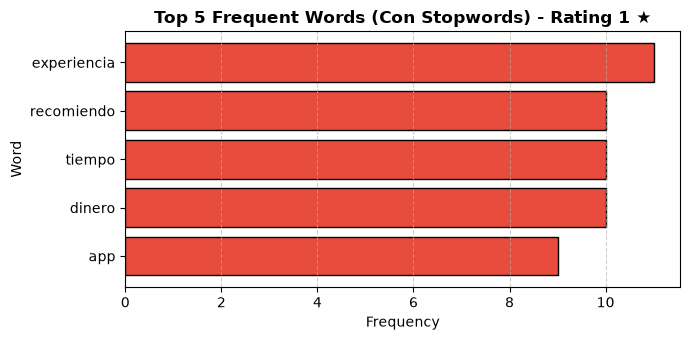

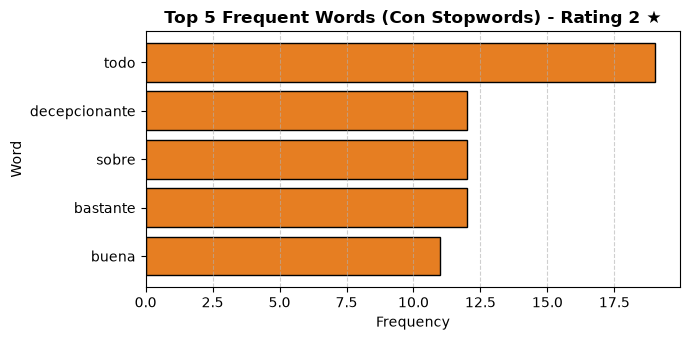

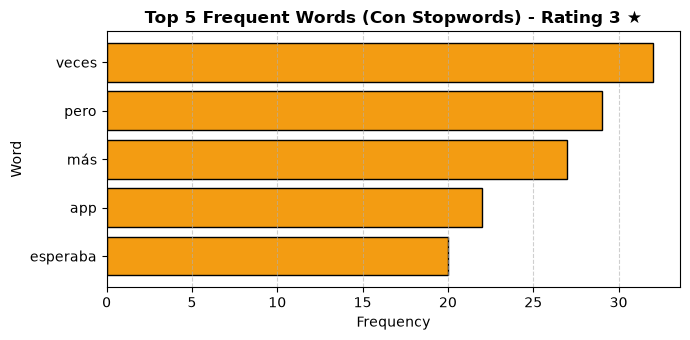

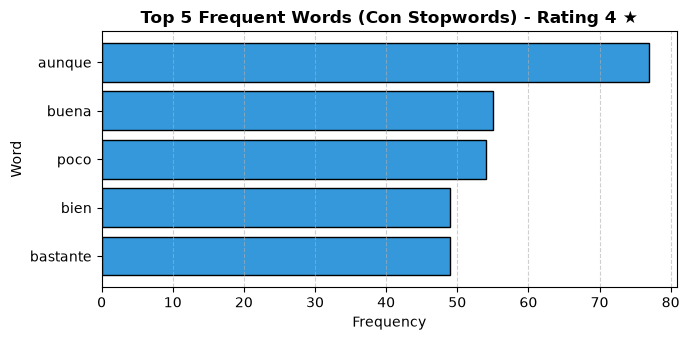

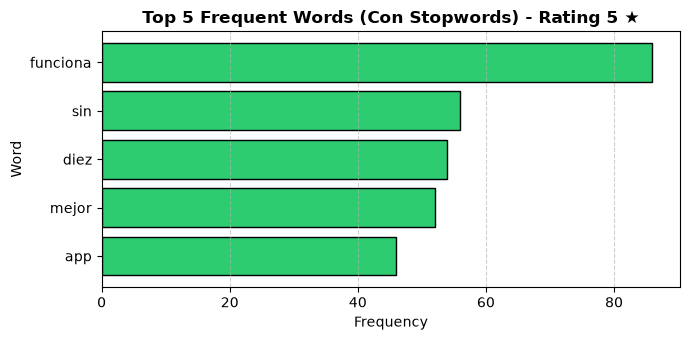

In [20]:
colors = {1: "#e74c3c", 2: "#e67e22", 3: "#f39c12", 4: "#3498db", 5: "#2ecc71"}

for r in [1, 2, 3, 4, 5]:
    plt.figure(figsize=(7, 3.5))
    sub_df = df_top_words_filtered[df_top_words_filtered["rating"] == r].sort_values(
        by="frequency", ascending=True
    )
    plt.barh(sub_df["word"], sub_df["frequency"], color=colors[r], edgecolor="black")
    plt.title(
        f"Top 5 Frequent Words (Con Stopwords) - Rating {r} ★",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Frequency", fontsize=10)
    plt.ylabel("Word", fontsize=10)
    plt.grid(axis="x", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

## 4. Conclusiones y Resumen

- **Descubrimiento de Datos (`eda_raw_summary`):** Se inspeccionó el archivo crudo `resenas_flowapp.csv` (597 filas), identificando 26 textos nulos/vacíos, ratings textuales o fuera del rango 1-5 (`'cinco'`, `NaN`, `-1`, `6`, `7`, `'?'`, `'N/A'`), y 54 textos duplicados.
- **Limpieza de Texto (`cleaned_reviews`):** Se eliminaron caracteres especiales y emojis, manteniendo palabras en minúsculas y números. La deduplicación filtró las reseñas duplicadas reduciéndolas a 418 reseñas únicas.
- **Resumen Estadístico:** El promedio de calificación es de **3.80** (`avg_rating`) con una mediana de **4.0** (`median_rating`), lo que muestra un sentimiento general positivo.
- **Comparación de Palabras Frecuentes:**
  - **Sin Stopwords (`top_words_raw`):** Los términos principales están dominados por artículos y preposiciones (*la*, *de*, *el*, *que*, *un*).
  - **Con Stopwords (`top_words_filtered`):** Al remover las stopwords, se destacan términos con valor semántico real. En 5 estrellas destacan *funciona*, *diez*, *mejor*, *app*, *increíble*; mientras que en calificaciones bajas (1-3 estrellas) se identifican áreas de dolor como *esperaba*, *falla*, *decepcionante*, *dinero*, *experiencia*.
- **Almacenamiento en DuckDB (`./out/`):** Todos los resultados se guardan de manera centralizada en `./out/flowapp_analysis.duckdb`.
